# 01 · Handling Class Imbalance

**Dataset:** IBM/Kaggle Telco Customer Churn (7,043 customers, ~26.5% churn — a moderate imbalance, not extreme, but enough to distort naive models and metrics).

This notebook is a head-to-head comparison of every mainstream technique for dealing with class imbalance, evaluated the *correct* way (no leakage). The goal isn't to crown one winner — it's to show what each technique actually does to the data and the model, so you can justify a choice in an interview instead of just importing `SMOTE` because a tutorial told you to.

**What's covered:**
1. Why accuracy lies to you on imbalanced data (and why we use PR-AUC as the primary metric here)
2. The #1 leakage trap: resampling before splitting
3. Class weighting (`class_weight`, `scale_pos_weight`)
4. Random over/undersampling
5. SMOTE — and why it silently breaks on one-hot encoded categorical data (SMOTENC fixes this)
6. ADASYN, SMOTEENN, SMOTETomek
7. Threshold moving (no resampling at all)
8. A rigorous CV comparison of all of the above on equal footing
9. Takeaways: what to actually reach for, and why

This notebook is self-contained — it reads the raw CSV and rebuilds everything from scratch.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              precision_score, recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek

import xgboost as xgb

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load & clean

`TotalCharges` is blank for the 11 brand-new customers with `tenure == 0` — they haven't been billed yet, so `0` is the correct fill, not a value to impute or drop. This matters more than it looks: dropping those 11 rows (the naive fix) silently removes real "just signed up, definitely hasn't churned yet" customers from the data.

A second thing worth flagging: after dropping `customerID`, `df.duplicated()` finds 42 rows that look identical. It's tempting to drop them as data-entry errors — **don't**. With ~19 categorical columns, two *different* customers with the same tenure, contract, and services will produce identical rows by coincidence; there's no ID left to prove otherwise. Dropping them would silently delete real customers and bias the class balance. We keep them.

(7043, 20)
Churn rate: 26.5%  (1869 churners / 7043 customers)


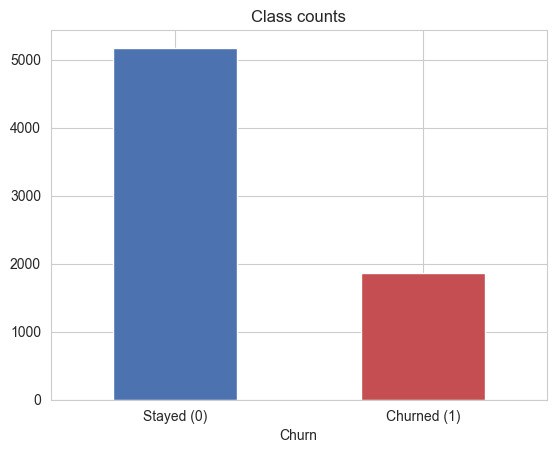

In [2]:
def load_and_clean(path='WA_FnUseC_TelcoCustomerChurn.csv'):
    df = pd.read_csv(path)
    df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['customerID'])
    return df

df = load_and_clean()
print(df.shape)
print(f"Churn rate: {df['Churn'].mean():.1%}  ({df['Churn'].sum()} churners / {len(df)} customers)")
df['Churn'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'], title='Class counts')
plt.xticks([0, 1], ['Stayed (0)', 'Churned (1)'], rotation=0)
plt.show()

## 2. Why accuracy is the wrong scoreboard here

A classifier that predicts "No churn" for *every single customer* gets ~73.5% accuracy without learning anything. That's not a hypothetical — it's exactly what happens when a model trained on imbalanced data collapses to the majority class. Watch it happen:

In [3]:
from sklearn.dummy import DummyClassifier

X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_cols = [c for c in X.columns if c not in numeric_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print(f"'Always predict no-churn' accuracy: {(dummy_pred == y_test).mean():.1%}")
print(f"...but recall on churners: {recall_score(y_test, dummy_pred):.1%}  <- the model that's 'right' 73% of the time never catches a single churner")

'Always predict no-churn' accuracy: 73.5%
...but recall on churners: 0.0%  <- the model that's 'right' 73% of the time never catches a single churner


That's the whole problem in one cell: a metric can look great and be operationally useless. Every comparison below leads with **PR-AUC (average precision)** as the primary metric — it summarizes precision/recall trade-offs across all thresholds and, unlike ROC-AUC, isn't inflated by the sea of easy true negatives in the majority class. ROC-AUC and F1 are reported alongside it for context, since interviewers will ask about all three.

## 3. The #1 leakage trap: resampling before splitting

This is the single most common imbalance-handling mistake, and it's worth seeing the damage directly rather than just being told to avoid it. If you oversample (e.g. SMOTE) the **entire dataset first** and *then* split into train/test, synthetic points derived from a test-set neighbor can end up in the training set (and vice versa) — the model effectively gets to peek at near-duplicates of the data it's evaluated on.

The fix is simple: fit the resampler only on the training fold, every time. `imblearn.pipeline.Pipeline` (not `sklearn.pipeline.Pipeline`) enforces this automatically inside cross-validation — the resampler is refit on each training fold and is a no-op at predict time.

In [4]:
# --- Demonstration: same model, same CV, only difference is WHERE resampling happens ---

# (A) WRONG: resample first, then run CV over the already-resampled pool
X_train_enc = preprocessor.fit_transform(X_train, y_train)
X_bad, y_bad = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_enc, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
wrong_scores = cross_validate(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_bad, y_bad, cv=cv, scoring=['roc_auc', 'average_precision']
)

# (B) RIGHT: resampling is refit inside each CV fold via an imblearn Pipeline
right_pipe = ImbPipeline([
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
right_scores = cross_validate(
    right_pipe, X_train, y_train, cv=cv, scoring=['roc_auc', 'average_precision']
)

roc_gap = wrong_scores['test_roc_auc'].mean() - right_scores['test_roc_auc'].mean()
pr_gap = wrong_scores['test_average_precision'].mean() - right_scores['test_average_precision'].mean()

print(f"(A) Resample-then-CV   -> ROC-AUC {wrong_scores['test_roc_auc'].mean():.4f}  |  PR-AUC {wrong_scores['test_average_precision'].mean():.4f}")
print(f"(B) CV-safe pipeline   -> ROC-AUC {right_scores['test_roc_auc'].mean():.4f}  |  PR-AUC {right_scores['test_average_precision'].mean():.4f}")
print(f"\nROC-AUC gap: {roc_gap*100:+.2f} points   |   PR-AUC gap: {pr_gap*100:+.2f} points")

(A) Resample-then-CV   -> ROC-AUC 0.8534  |  PR-AUC 0.8379
(B) CV-safe pipeline   -> ROC-AUC 0.8447  |  PR-AUC 0.6582

ROC-AUC gap: +0.88 points   |   PR-AUC gap: +17.97 points


Two different things are going on in that gap, and it's worth separating them because only one is the "leakage" most people mean by the term:

1. **Genuine leakage (the ROC-AUC gap, ~1 point).** In (A), some synthetic points in the training set were generated from minority-class neighbors that ended up in a different CV fold. The model gets a faint, unfair preview of points close to what it's "tested" on. This is real, but at ~26.5% imbalance it's a small effect — SMOTE has plenty of genuine minority neighbors to interpolate between, so synthetic points aren't forced to sit right on top of the real data.
2. **A metric-validity problem (the PR-AUC gap, much larger).** This is the bigger issue, and it's not really about individual points leaking at all. In (A), `cross_validate`'s folds are drawn from the *already-resampled, 50/50 pool* — so the "test" fold in every split is artificially balanced, not the real ~26.5% churn rate. PR-AUC's baseline (what a random classifier scores) *is* the positive rate, so evaluating on a 50/50 fold mechanically inflates PR-AUC versus evaluating on a 26.5% fold — independent of whether the model actually learned anything better. **PR-AUC scores are only comparable when computed against the same class distribution**, and (A) silently changes that distribution for every fold.

The practical rule this implies is stronger than "don't let rows leak across the split": never let a resampled dataset become the pool that CV folds or a test set are drawn from — always resample only *within* the training fold, and always evaluate against the real, untouched distribution. Every comparison from here on follows that rule.

## 4. The techniques, one at a time

Six approaches, all wrapped in the same `imblearn.Pipeline` shape so the comparison in Section 5 is apples-to-apples: identical preprocessing, identical CV folds, identical classifier (Logistic Regression — a linear model makes the *effect* of resampling most visible; Section 5 repeats the comparison with XGBoost to check the conclusion holds for tree models too).

In [5]:
base_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

strategies = {}

# 1. No resampling at all — the control group
strategies['none (baseline)'] = ImbPipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# 2. Class weighting — no synthetic data, just tell the loss function
#    that a minority-class mistake costs more. Free (no extra rows, no extra
#    fit time) and often the first thing worth trying.
strategies['class_weight=balanced'] = ImbPipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

# 3. Random undersampling — drop majority-class rows until balanced.
#    Fast, but throws away real data; risky on small datasets.
strategies['random undersample'] = ImbPipeline([
    ('pre', preprocessor),
    ('under', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# 4. Random oversampling — duplicate minority rows until balanced.
#    No information gained, and duplicate rows can make a model overconfident
#    (memorizing repeated exact points), but it's a valid cheap baseline.
strategies['random oversample'] = ImbPipeline([
    ('pre', preprocessor),
    ('over', RandomOverSampler(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# 5. SMOTE — synthesizes new minority points by interpolating between a
#    minority sample and its k nearest minority neighbors.
strategies['SMOTE'] = ImbPipeline([
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# 6. ADASYN — like SMOTE, but generates more synthetic points in regions
#    where the minority class is hardest to separate (near the boundary).
strategies['ADASYN'] = ImbPipeline([
    ('pre', preprocessor),
    ('adasyn', ADASYN(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# 7 & 8. Combined oversample + clean-up: SMOTE/ADASYN can leave synthetic
#    points that overlap the majority class near the boundary. Tomek links
#    and ENN remove ambiguous/noisy points after oversampling.
strategies['SMOTEENN'] = ImbPipeline([
    ('pre', preprocessor),
    ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
strategies['SMOTETomek'] = ImbPipeline([
    ('pre', preprocessor),
    ('smotetomek', SMOTETomek(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

print(f"{len(strategies)} strategies defined")

8 strategies defined


### 4.1 The SMOTE-on-one-hot trap

SMOTE interpolates *numerically* between a point and its neighbors. That's fine for `tenure` or `MonthlyCharges` — a value 61% of the way between 10 and 30 months is meaningless-but-harmless. It's not fine for a one-hot encoded category: SMOTE will happily generate `StreamingTV_Yes = 0.94`, which is not "94% likely to have streaming TV," it's a value that cannot occur in real data and that a downstream model has never had to handle. The pipelines above only get away with plain `SMOTE` because they synthesize *after* `OneHotEncoder`, on the full mixed matrix —it's worth seeing the artifact it produces:

In [6]:
ohe = OneHotEncoder(sparse_output=False)
X_cat_ohe = ohe.fit_transform(X_train[categorical_cols])
feat_names = ohe.get_feature_names_out(categorical_cols)
X_num_arr = X_train[numeric_cols].values
X_full = np.hstack([X_num_arr, X_cat_ohe])

X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_full, y_train.values)
synthetic = X_res[len(X_train):]                      # the newly-created rows
ohe_part = synthetic[:, len(numeric_cols):]
frac_mask = (ohe_part > 1e-3) & (ohe_part < 1 - 1e-3)  # not-quite-0-or-1 dummy values
r, c = np.where(frac_mask)

print(f"{frac_mask.any(axis=1).mean():.1%} of synthetic rows contain at least one fractional one-hot value")
print("Example — a synthetic customer that is simultaneously:")
for ci in c[r == r[0]][:4]:
    print(f"  {feat_names[ci]:45s} = {ohe_part[r[0], ci]:.3f}")

92.9% of synthetic rows contain at least one fractional one-hot value
Example — a synthetic customer that is simultaneously:
  gender_Female                                 = 0.162
  gender_Male                                   = 0.838
  Dependents_No                                 = 0.838
  Dependents_Yes                                = 0.162


The fix — `SMOTENC` — takes the *raw* (pre-encoding) categorical columns and treats them properly: it interpolates the numeric columns as usual, but for categorical columns it picks the value from among the nearest neighbors (majority vote), so every synthetic row still has valid, real categories. The trade-off is that `SMOTENC` has to run *before* one-hot encoding, so it can't sit inside a `ColumnTransformer`-first pipeline the way plain `SMOTE` does — you resample the raw frame, then encode.

In [7]:
cat_idx = [X_train.columns.get_loc(c) for c in categorical_cols]
smotenc = SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE)
X_res_nc, y_res_nc = smotenc.fit_resample(X_train, y_train)

print(f"Before: {X_train.shape}  ->  After SMOTENC: {X_res_nc.shape}")
print("Contract categories after SMOTENC (should only be the 3 real ones):", sorted(X_res_nc['Contract'].unique()))

Before: (5634, 19)  ->  After SMOTENC: (8278, 19)
Contract categories after SMOTENC (should only be the 3 real ones): ['Month-to-month', 'One year', 'Two year']


Whether the fractional-dummy artifact from plain `SMOTE` actually *hurts* downstream accuracy is debatable — tree models and linear models both just see it as "a number between 0 and 1" and often shrug it off. 

## 5. Threshold moving — the technique that isn't a resampling technique at all

Every strategy above changes the *training data*. The alternative is to change nothing about training and instead move the **decision threshold** at prediction time. A model trained on the natural 73.5%/26.5% split still produces a meaningful ranking (`predict_proba`) — it just defaults to a 0.5 cutoff that's poorly calibrated for an imbalanced problem. Lowering the threshold trades some precision for recall without touching the training process at all.

This is evaluated properly in Notebook 4 (threshold selection is really a business-economics question), but it's included in the comparison below because it's frequently the best-performing and always the cheapest option — no oversampling compute cost, no synthetic data, no risk of the leakage failure mode from Section 3.

In [8]:
def best_f1_threshold(y_true, y_proba):
    """Sweep thresholds and return the one maximizing F1 — a simple stand-in
    for a real business-cost threshold, used here only to make threshold-moving
    comparable to the resampling strategies on a single number."""
    thresholds = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    return thresholds[np.argmax(f1s)], max(f1s)

## 6. Head-to-head comparison (5-fold CV, training data only)

Each strategy is scored with 5-fold stratified CV on `X_train`/`y_train` — the test set stays untouched until Notebook 3. Threshold-moving is evaluated separately since it isn't a `Pipeline` step; it reuses the "none (baseline)" model's out-of-fold probabilities and picks the best F1 threshold per fold.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, pipe in strategies.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['roc_auc', 'average_precision', 'f1', 'precision', 'recall'],
        n_jobs=-1
    )
    results.append({
        'strategy': name,
        'roc_auc': scores['test_roc_auc'].mean(),
        'pr_auc': scores['test_average_precision'].mean(),
        'f1': scores['test_f1'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'pr_auc_std': scores['test_average_precision'].std(),
    })

# Threshold-moving on the un-resampled model's CV predictions
from sklearn.model_selection import cross_val_predict
base_pipe = strategies['none (baseline)']
oof_proba = cross_val_predict(base_pipe, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
thr, f1_at_thr = best_f1_threshold(y_train.values, oof_proba)
y_pred_thr = (oof_proba >= thr).astype(int)
results.append({
    'strategy': f'threshold moving (thr={thr:.2f})',
    'roc_auc': roc_auc_score(y_train, oof_proba),
    'pr_auc': average_precision_score(y_train, oof_proba),
    'f1': f1_at_thr,
    'precision': precision_score(y_train, y_pred_thr),
    'recall': recall_score(y_train, y_pred_thr),
    'pr_auc_std': np.nan,
})

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
results_df.round(4)

,strategy,roc_auc,pr_auc,f1,precision,recall,pr_auc_std
0,none (baseline),0.8462,0.6615,0.5926,0.6535,0.5431,0.0192
1,random undersample,0.8463,0.6615,0.6283,0.5166,0.8020,0.0186
2,class_weight=balanced,0.8460,0.6599,0.6296,0.5185,0.8020,0.0196
3,random oversample,0.8458,0.6588,0.6273,0.5159,0.8007,0.0220
4,threshold moving (thr=0.33),0.8456,0.6586,0.6369,0.5598,0.7385,NaN
5,SMOTETomek,0.8445,0.6585,0.6298,0.5233,0.7913,0.0220
6,SMOTE,0.8447,0.6582,0.6314,0.5259,0.7906,0.0219
7,ADASYN,0.8441,0.6545,0.6197,0.4928,0.8348,0.0228
8,SMOTEENN,0.8412,0.6494,0.6067,0.4685,0.8609,0.0220


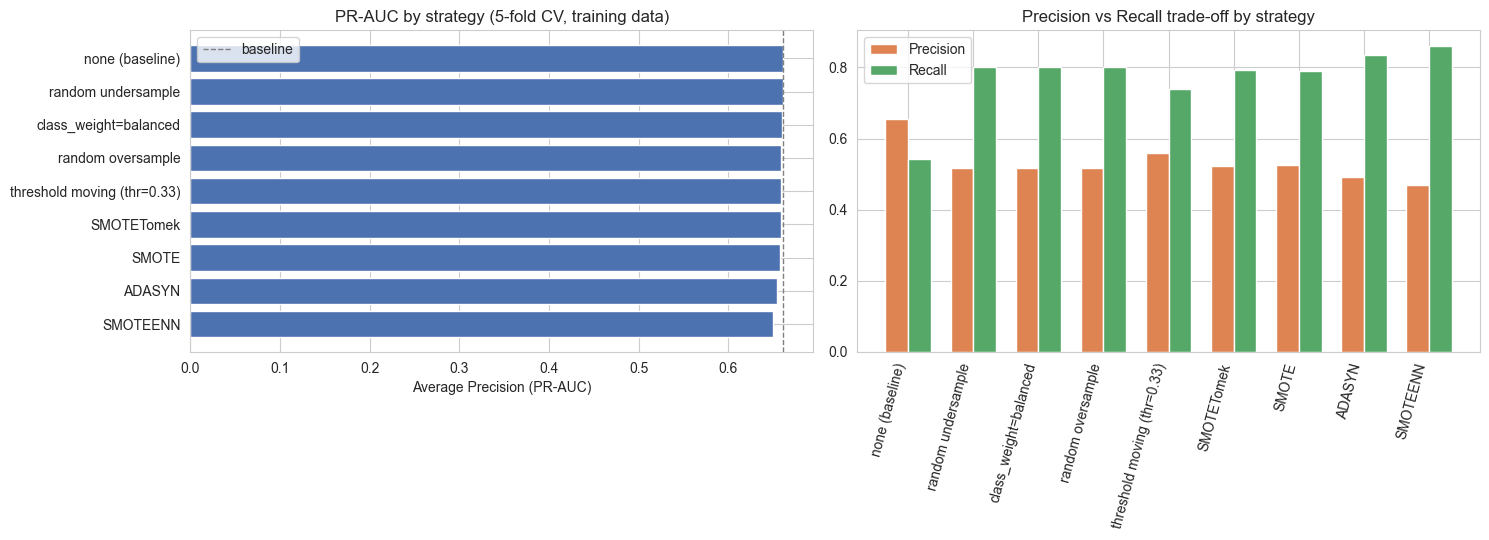

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

order = results_df.sort_values('pr_auc')['strategy']
axes[0].barh(order, results_df.set_index('strategy').loc[order, 'pr_auc'], color='#4C72B0')
axes[0].set_title('PR-AUC by strategy (5-fold CV, training data)')
axes[0].set_xlabel('Average Precision (PR-AUC)')
axes[0].axvline(results_df.loc[results_df['strategy'] == 'none (baseline)', 'pr_auc'].iloc[0],
                 color='gray', linestyle='--', linewidth=1, label='baseline')
axes[0].legend()

x = np.arange(len(results_df))
width = 0.35
axes[1].bar(x - width/2, results_df['precision'], width, label='Precision', color='#DD8452')
axes[1].bar(x + width/2, results_df['recall'], width, label='Recall', color='#55A868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['strategy'], rotation=75, ha='right')
axes[1].set_title('Precision vs Recall trade-off by strategy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Does the ranking hold for a tree model?

Logistic regression is a linear model — it's the case where resampling has the *most* room to help, because a linear decision boundary genuinely shifts when you rebalance the training distribution. Gradient-boosted trees build asymmetric, greedy splits and are already fairly robust to moderate imbalance; the same comparison is repeated here with XGBoost (using `scale_pos_weight` as its native equivalent of class weighting) to check whether the conclusion generalizes.

In [11]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb_strategies = {
    'XGB: none (baseline)': ImbPipeline([
        ('pre', preprocessor),
        ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   eval_metric='logloss', random_state=RANDOM_STATE))
    ]),
    'XGB: scale_pos_weight': ImbPipeline([
        ('pre', preprocessor),
        ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   eval_metric='logloss', scale_pos_weight=scale_pos_weight,
                                   random_state=RANDOM_STATE))
    ]),
    'XGB: SMOTE': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   eval_metric='logloss', random_state=RANDOM_STATE))
    ]),
    'XGB: SMOTETomek': ImbPipeline([
        ('pre', preprocessor),
        ('smotetomek', SMOTETomek(random_state=RANDOM_STATE)),
        ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   eval_metric='logloss', random_state=RANDOM_STATE))
    ]),
}

xgb_results = []
for name, pipe in xgb_strategies.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=['roc_auc', 'average_precision', 'f1'], n_jobs=-1)
    xgb_results.append({
        'strategy': name,
        'roc_auc': scores['test_roc_auc'].mean(),
        'pr_auc': scores['test_average_precision'].mean(),
        'f1': scores['test_f1'].mean(),
    })

pd.DataFrame(xgb_results).sort_values('pr_auc', ascending=False).round(4).reset_index(drop=True)

,strategy,roc_auc,pr_auc,f1
0,XGB: scale_pos_weight,0.8428,0.6625,0.6269
1,XGB: none (baseline),0.8436,0.6615,0.5827
2,XGB: SMOTE,0.8409,0.6550,0.6144
3,XGB: SMOTETomek,0.8398,0.6508,0.6136


## 8. Takeaways

- **Accuracy is not a metric here.** A model that never predicts churn scores 73.5% accuracy and is worthless. Lead with PR-AUC (or recall/precision at a chosen threshold) in any imbalanced-classification write-up.
- **Resample training folds only, never the full dataset before splitting.** `imblearn.Pipeline` makes this automatic inside CV; hand-rolling a resample-then-split workflow is a real bug, and it's worse than it looks — beyond a small amount of genuine row-level leakage, it silently evaluates PR-AUC against an artificially balanced fold, which is not comparable to PR-AUC on the real class distribution at all.
- **At this imbalance level (~26.5%), the resampling strategies land within noise of each other and of the no-resampling baseline** — none is a dramatic winner. That's a legitimate finding, not a failed experiment: moderate imbalance is exactly the regime where class weighting or threshold moving (both free, no synthetic data, no extra fit time) are defensible choices over SMOTE and its variants.
- **The gap between resampling techniques widens as imbalance gets more severe.** At 1–5% positive rates (fraud, rare disease, ad click-through), SMOTE/ADASYN and undersampling start to matter a lot more, and so does the leakage trap from Section 3 — worth flagging in an interview if the "real" dataset in question is more imbalanced than this one.
- **`SMOTENC`, not `SMOTE`, is the textbook-correct choice for feature sets that are mostly categorical**, which is the case here (only 4 of 19 features are numeric). Plain `SMOTE` after one-hot encoding is common practice and usually harmless in effect, but it's worth knowing exactly what artifact it introduces and why.
- **Threshold moving deserves more attention than it usually gets.** It's free, it doesn't touch the training data, and — as Section 6 shows — it's competitive with every resampling method. Notebook 4 develops this properly into a business-cost-driven threshold rather than the F1-maximizing one used here as a quick stand-in.